# 01 - Construccion y analisis del corpus sintetico

**Proyecto Final CS 3061 - Machine Learning**
Clasificacion multilingue de intenciones de atencion al cliente sobre WhatsApp.

Este notebook construye el corpus sintetico de **1320 mensajes** (12 intenciones,
110 por clase) en espanol, ingles y portugues mediante *slot-filling* sobre
plantillas y una capa de ruido superficial controlado, y realiza el analisis
exploratorio.


In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'corpus'))
import importlib, generar_corpus as gc
importlib.reload(gc)
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', 80)


## 1. Taxonomia de intenciones

Doce intenciones organizadas en tres familias, tal como se definio en el primer informe.

In [2]:
familias = {
 'Transaccionales verticales': ['constituir_empresa','comprar_pizza','reservar_hotel',
     'comprar_vuelo','consultar_medicina','agendar_cita_medica','consulta_banca'],
 'Genericas de servicio': ['soporte_tecnico','reclamo','seguimiento_pedido'],
 'Conversacionales': ['saludo','despedida'],
}
for f, xs in familias.items():
    print(f'{f}:'); print('   ', ', '.join(xs))


Transaccionales verticales:
    constituir_empresa, comprar_pizza, reservar_hotel, comprar_vuelo, consultar_medicina, agendar_cita_medica, consulta_banca
Genericas de servicio:
    soporte_tecnico, reclamo, seguimiento_pedido
Conversacionales:
    saludo, despedida


## 2. Generacion del corpus

El generador combina plantillas por idioma con vocabularios de *slots*
(ciudades, sintomas, especialidades, productos, etc.). Un 30% de cada clase
proviene de plantillas **ambiguas** que comparten vocabulario con una clase
vecina, reproduciendo las fronteras lexicas reales (p. ej. "mi cuenta no
funciona" es compartida por `consulta_banca` y `soporte_tecnico`).

In [3]:
gc.main()   # genera corpus/corpus.csv de forma reproducible (seed=42)
df = pd.read_csv(os.path.join('..','corpus','corpus.csv'))
print('Dimension:', df.shape)
df.sample(10, random_state=1)


Corpus generado: 1320 mensajes -> /Users/rodrigo/Documents/ec1_machine_learning/proyecto-final/corpus/corpus.csv
Por intencion: {'constituir_empresa': 110, 'consultar_medicina': 110, 'comprar_vuelo': 110, 'reclamo': 110, 'agendar_cita_medica': 110, 'seguimiento_pedido': 110, 'reservar_hotel': 110, 'comprar_pizza': 110, 'saludo': 110, 'despedida': 110, 'soporte_tecnico': 110, 'consulta_banca': 110}
Por idioma: {'es': 924, 'pt': 132, 'en': 264}
Dimension: (1320, 3)


,text,intent,lang
288,"me antojo una ed peperoni, tienen promo?",comprar_pizza,es
190,cuanto tengo disponible en mi cuenta de ahorros?,consulta_banca,es
853,Hola que tal,saludo,es
1085,i cant transfer money from my cacount,consulta_banca,en
186,"ok muchas gracias, chau urgente ❤️",despedida,es
258,Deseo una pizza napoitana grande con extra queso 😀,comprar_pizza,es
585,hay disponibilidad en un hotel cerca del centro pa el viernes?,reservar_hotel,es
1081,Preciso de ajuda para formalizar um pequeno negocio urgente,constituir_empresa,pt
1274,como solicito un aumento de linea de credito? gracias,consulta_banca,es
893,deseo una pizza pepperoni grande con extra queso urgente 👍,comprar_pizza,es


## 3. Distribucion por intencion e idioma

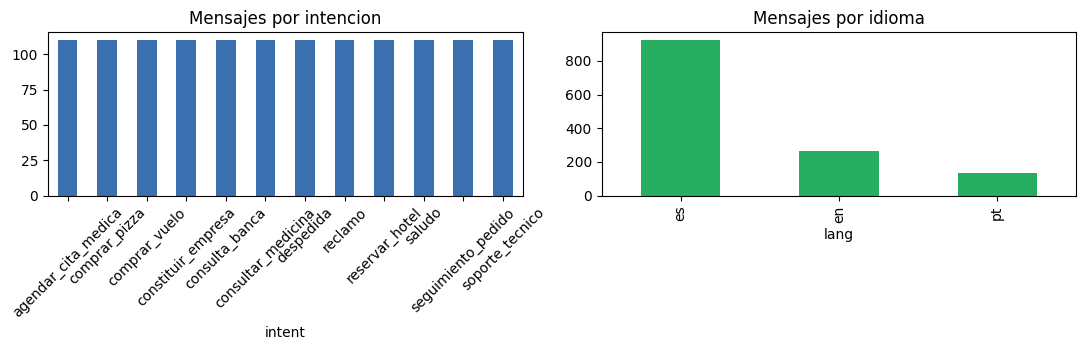

{'es': 0.7, 'en': 0.2, 'pt': 0.1}


In [4]:
fig, ax = plt.subplots(1,2, figsize=(11,3.6))
df['intent'].value_counts().sort_index().plot.bar(ax=ax[0], color='#3b6fb0')
ax[0].set_title('Mensajes por intencion'); ax[0].tick_params(axis='x', labelrotation=45)
df['lang'].value_counts().plot.bar(ax=ax[1], color='#27ae60')
ax[1].set_title('Mensajes por idioma')
plt.tight_layout(); plt.show()
print(df['lang'].value_counts(normalize=True).round(3).to_dict())


## 4. Longitud de los mensajes y ejemplos de ambiguedad

In [5]:
df['n_tokens'] = df['text'].str.split().map(len)
print(df['n_tokens'].describe().round(2))
print('\nMensajes que contienen "cuenta" (frontera banca/soporte):')
print(df[df['text'].str.contains('cuenta')].groupby('intent').size())


count    1320.00
mean        7.24
std         2.02
min         2.00
25%         6.00
50%         7.00
75%         9.00
max        13.00
Name: n_tokens, dtype: float64

Mensajes que contienen "cuenta" (frontera banca/soporte):
intent
consulta_banca     57
soporte_tecnico    29
dtype: int64


In [6]:
# ejemplos de la frontera lexica compartida
mask = df['text'].str.contains('cuenta') & df['intent'].isin(['consulta_banca','soporte_tecnico'])
df[mask].sample(8, random_state=3)[['text','intent']]


,text,intent
938,Mi cuenta me da error gracias,soporte_tecnico
1245,cual es el saldo de mi cuenta? po favor 🏨,consulta_banca
190,cuanto tengo disponible en mi cuenta de ahorros?,consulta_banca
1275,No puedo acceder a mi cuenta,soporte_tecnico
672,mi cuenta me da error,soporte_tecnico
1261,Cuanto tengo disponible en mi cuenta de ahorros?,consulta_banca
1292,"mi cuenta no me deja hacer pagos, que paasa? ✈️",consulta_banca
802,No puedo entrar a mi cuenta por favor,consulta_banca


El corpus queda guardado en `corpus/corpus.csv` y es la entrada de los
notebooks siguientes. La construccion es totalmente reproducible (semilla fija).
